In [82]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from dmba import AIC_score
from dmba import stepwise_selection


In [83]:
disease = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/LungDisease.csv")
disease


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1
...,...,...
117,450,22
118,490,22
119,500,22
120,370,23


<Axes: xlabel='Exposure', ylabel='PEFR'>

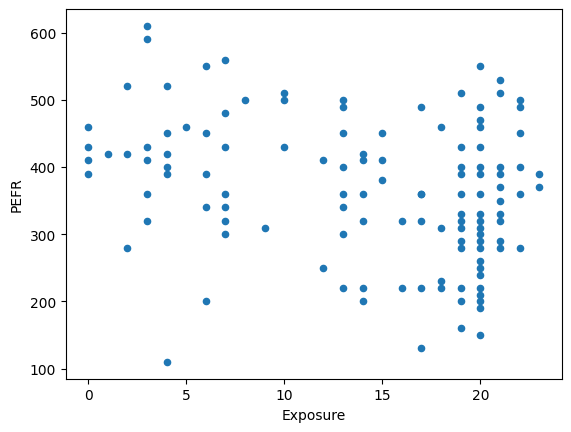

In [84]:
disease.plot.scatter(x="Exposure", y="PEFR")

In [85]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(disease[predictors], disease[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


In [86]:
fitted = model.predict(disease[predictors])
residuals = disease.PEFR - fitted

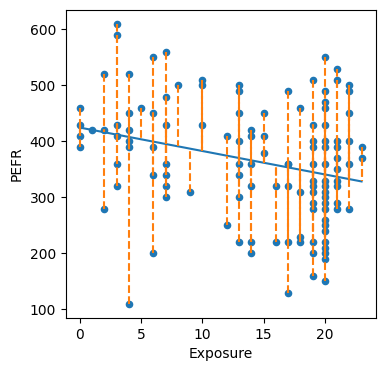

In [87]:
ax = disease.plot.scatter(x="Exposure", y="PEFR", figsize=(4,4))
ax.plot(disease.Exposure, fitted)
for x, y_actual, y_fitted in zip(disease.Exposure, disease.PEFR, fitted):
    ax.plot((x,x), (y_actual, y_fitted), "--", color="C1")

In [88]:
house = pd.read_csv("data/house_sales.csv",sep="\t")
house

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27057,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,1.75,3,7,1951,0,0,201000,172000,98126,False
27058,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,4.50,4,11,2000,0,1,703000,951000,98040,False
27061,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,1.00,4,6,1971,0,0,92000,130000,98055,False
27062,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,2.00,3,7,1939,0,0,103000,212000,98166,False


In [89]:
house.info

<bound method DataFrame.info of       DocumentDate  SalePrice  PropertyID   PropertyType          ym  zhvi_px  \
1       2014-09-16     280000     1000102      Multiplex  2014-09-01   405100   
2       2006-06-16    1000000     1200013  Single Family  2006-06-01   404400   
3       2007-01-29     745000     1200019  Single Family  2007-01-01   425600   
4       2008-02-25     425000     2800016  Single Family  2008-02-01   418400   
5       2013-03-29     240000     2800024  Single Family  2013-03-01   351600   
...            ...        ...         ...            ...         ...      ...   
27057   2011-04-08     325000  9842300710  Single Family  2011-04-01   318700   
27058   2007-09-28    1580000  9845500010  Single Family  2007-09-01   433500   
27061   2012-07-09     165000  9899200010  Single Family  2012-07-01   325300   
27062   2006-05-26     315000  9900000355  Single Family  2006-05-01   400600   
27063   2007-01-09     465000  9906000035  Single Family  2007-01-01   425600

In [90]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms',
'Bedrooms', 'BldgGrade']
house[subset]

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7
...,...,...,...,...,...,...
27057,443803.0,1480,5468,1.75,3,7
27058,1586196.0,4720,23914,4.50,4,11
27061,220744.0,1070,11170,1.00,4,6
27062,342207.0,1345,6223,2.00,3,7


In [91]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(X=house[predictors], y=house[outcome])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
house_lm.intercept_

np.float64(-521871.3681882868)

In [93]:
for key, coef in zip(predictors, house_lm.coef_):
    print(f"{key}: {coef}")

SqFtTotLiving: 228.8306036024079
SqFtLot: -0.06046682065304834
Bathrooms: -19442.8403983211
Bedrooms: -47769.95518521415
BldgGrade: 106106.96307898109


In [94]:
fitted_house = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted_house))
r2 = r2_score(house[outcome], fitted_house)

print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


In [95]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sun, 14 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:20:08   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
const         -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

(100, 1)
Base MAE: 1.5496734341733023


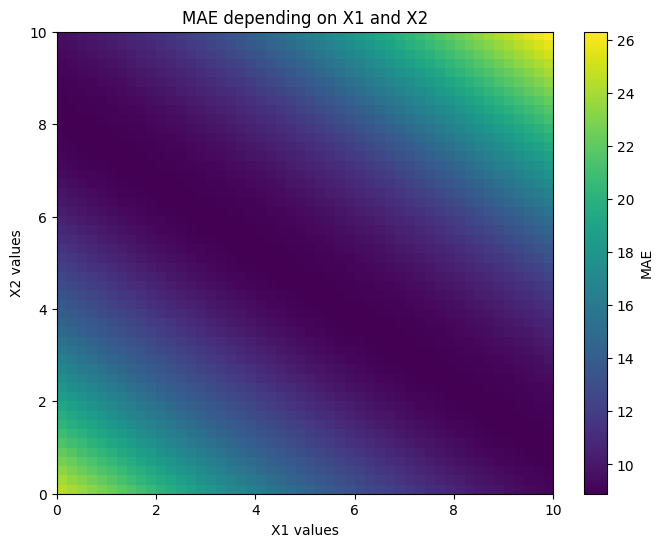

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Example dataset
np.random.seed(42)
X1 = np.random.rand(100, 1) * 10
X2 = np.random.rand(100, 1) * 10
print(X1.shape)
y = 3*X1 + 2*X2 + np.random.randn(100, 1) * 2  # true model with noise

X = np.hstack([X1, X2])

# Train model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
base_mae = mean_absolute_error(y, y_pred)

print("Base MAE:", base_mae)

# --- Create a grid of values for X1 and X2 ---
grid_x1 = np.linspace(0, 10, 50)
grid_x2 = np.linspace(0, 10, 50)
mae_matrix = np.zeros((len(grid_x1), len(grid_x2)))

# Calculate MAE if we "force" predictions using only grid values
for i, v1 in enumerate(grid_x1):
    for j, v2 in enumerate(grid_x2):
        X_grid = np.column_stack([np.full_like(X1, v1), np.full_like(X2, v2)])
        y_grid_pred = model.predict(X_grid)
        mae_matrix[i, j] = mean_absolute_error(y, y_grid_pred)

# --- Plot heatmap ---
plt.figure(figsize=(8,6))
plt.imshow(mae_matrix, origin='lower', extent=[0,10,0,10], aspect='auto', cmap="viridis")
plt.colorbar(label="MAE")
plt.xlabel("X1 values")
plt.ylabel("X2 values")
plt.title("MAE depending on X1 and X2")
plt.show()


In [97]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], dtype=int, drop_first=True)
X["NewConstruction"] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

X

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Sun, 14 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:20:08   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,NbrLivingUnits,SqFtFinBasement,YrBuilt,YrRenovated,NewConstruction,PropertyType_Single Family,PropertyType_Townhouse
1,2400,9373,3.00,6,7,2,0,1991,0,0,0,0
2,3764,20156,3.75,4,10,1,1452,2005,0,1,1,0
3,2060,26036,1.75,4,8,1,900,1947,0,0,1,0
4,3200,8618,3.75,5,7,1,1640,1966,0,0,1,0
5,1720,8620,1.75,4,7,1,0,1948,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27057,1480,5468,1.75,3,7,1,590,1951,0,0,1,0
27058,4720,23914,4.50,4,11,1,910,2000,0,0,1,0
27061,1070,11170,1.00,4,6,1,0,1971,0,0,1,0
27062,1345,6223,2.00,3,7,1,0,1939,0,0,1,0


#### Using Stepwise regression
to find the best features to predict the cost

In [98]:
y = house[outcome]

def train_model(vars):
    if len(vars) == 0:
        return None
    model = LinearRegression()
    model.fit(X[vars], y)
    return model

def score_model(model, vars):
    if len(vars) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[vars]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, verbose=True)
print()
print(f'Intercept: {best_model.intercept_:.3f}')
print("coefficients:")
for key, coef in zip(best_variables, best_model.coef_):
    print(f"{key}: {coef}")

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
coefficients:
SqFtTotLiving: 199.2775530420155
BldgGrade: 137159.5602262011
YrBuilt: -3565.4249392493457
Bedrooms: -51947.38367361445
Bathrooms: 42396.164527720204
PropertyType_Townhouse: 84479.16203299582
SqFtFinBasement: 7.046974967577223
PropertyType_Single Family: 22912.055187017522


In [99]:
house["year"] = [int(date.split("-")[0]) for date in house.DocumentDate]
house["weight"] = house.year - 2005

In [100]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.weight)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
pd.concat([
    pd.DataFrame({"predictor": predictors,
                "house_lm": house_lm.coef_,
                "house_wt": house_wt.coef_}),
    pd.DataFrame({"predictor": ["intercept"],
                  "house_lm": house_lm.intercept_,
                  "house_wt": house_wt.intercept_})
])


,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


In [102]:
house

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,year,weight
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,7,1991,0,0,70000,229000,98002,False,2014,9
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,10,2005,0,0,203000,590000,98166,True,2006,1
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,8,1947,0,0,183000,275000,98166,False,2007,2
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,7,1966,0,0,104000,229000,98168,False,2008,3
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,7,1948,0,0,104000,205000,98168,False,2013,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27057,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,7,1951,0,0,201000,172000,98126,False,2011,6
27058,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,11,2000,0,1,703000,951000,98040,False,2007,2
27061,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,6,1971,0,0,92000,130000,98055,False,2012,7
27062,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,7,1939,0,0,103000,212000,98166,False,2006,1


In [103]:
set(house.PropertyType)

{'Multiplex', 'Single Family', 'Townhouse'}

In [104]:
pd.get_dummies(house.PropertyType, drop_first=True)

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False
...,...,...
27057,True,False
27058,True,False
27061,True,False
27062,True,False


In [105]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
'BldgGrade', 'PropertyType']

x = pd.get_dummies(house[predictors], drop_first=True)
house_lm_factor = LinearRegression()
house_lm_factor.fit(x, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(x.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.3736289250383
 SqFtLot: -0.07036798136813079
 Bathrooms: -15979.013473415222
 Bedrooms: -50889.73218483015
 BldgGrade: 109416.30516146214
 PropertyType_Single Family: -84678.21629549282
 PropertyType_Townhouse: -115121.97921609192


In [106]:
pd.DataFrame(house.ZipCode.value_counts()).transpose()

ZipCode,98038,98103,98042,98115,98117,98052,98034,98033,98059,98074,...,98051,98024,98354,98050,98057,98288,98224,98068,98113,98043
count,788,671,641,620,619,614,575,517,513,502,...,32,31,9,7,4,4,3,1,1,1


In [107]:
a = np.array([[1,-1,3],
          [3,1,1],
          [-1,2,8]])

a @ a

array([[-5,  4, 26],
       [ 5,  0, 18],
       [-3, 19, 63]])

In [108]:
house = pd.read_csv("data/house_sales.csv",sep="\t")

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

zip_residuals = pd.DataFrame({
    "zip_code": house.ZipCode,
    "residual": house[outcome] - house_lm.predict(house[predictors])
})

zip_residuals

,zip_code,residual
1,98002,-123750.814194
2,98166,-59145.413089
3,98166,190108.725716
4,98168,-198788.774412
5,98168,-91774.996129
...,...,...
27057,98126,61921.802132
27058,98040,140828.931399
27061,98055,72322.919386
27062,98166,-3875.703833


In [109]:
zip_groups = pd.DataFrame([
    {
        "zip_code": zip_code,
        "count": len(i),
        "median_residual": i.residual.median()
    }
    for zip_code, i in zip_residuals.groupby("zip_code")
]).sort_values("median_residual")

zip_groups

,zip_code,count,median_residual
36,98057,4,-537321.644462
27,98043,1,-307661.343614
46,98092,289,-193569.183599
23,98038,788,-150066.477035
31,98051,32,-142352.869593
...,...,...,...
60,98119,260,174462.549290
54,98112,357,232788.487256
25,98040,244,254004.002463
3,98004,293,383596.028729


In [110]:
zip_groups["cum_count"] = np.cumsum(zip_groups["count"])
zip_groups["zip_group"] = pd.qcut(zip_groups.cum_count, 5, labels=False, retbins=False)
zip_groups

,zip_code,count,median_residual,cum_count,zip_group
36,98057,4,-537321.644462,4,0
27,98043,1,-307661.343614,5,0
46,98092,289,-193569.183599,294,0
23,98038,788,-150066.477035,1082,0
31,98051,32,-142352.869593,1114,0
...,...,...,...,...,...
60,98119,260,174462.549290,21746,4
54,98112,357,232788.487256,22103,4
25,98040,244,254004.002463,22347,4
3,98004,293,383596.028729,22640,4


In [111]:
zip_groups["cum_count"].describe()

count       80.000000
mean     11096.675000
std       6526.323073
min          4.000000
25%       6459.000000
50%      10382.500000
75%      16318.750000
max      22687.000000
Name: cum_count, dtype: float64

In [112]:
print(zip_groups.zip_group.value_counts().sort_index())

zip_group
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


In [113]:
to_join = zip_groups[["zip_code", "zip_group"]].set_index("zip_code")
house = house.join(to_join, on="ZipCode")


In [114]:
house["zip_group"] = house["zip_group"].astype("category")
house

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,zip_group
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,6,7,1991,0,0,70000,229000,98002,False,2
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,4,10,2005,0,0,203000,590000,98166,True,2
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,4,8,1947,0,0,183000,275000,98166,False,2
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,5,7,1966,0,0,104000,229000,98168,False,2
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,4,7,1948,0,0,104000,205000,98168,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27057,2011-04-08,325000,9842300710,Single Family,2011-04-01,318700,0.732307,443803.0,1,5468,...,3,7,1951,0,0,201000,172000,98126,False,3
27058,2007-09-28,1580000,9845500010,Single Family,2007-09-01,433500,0.996094,1586196.0,1,23914,...,4,11,2000,0,1,703000,951000,98040,False,4
27061,2012-07-09,165000,9899200010,Single Family,2012-07-01,325300,0.747472,220744.0,1,11170,...,4,6,1971,0,0,92000,130000,98055,False,0
27062,2006-05-26,315000,9900000355,Single Family,2006-05-01,400600,0.920496,342207.0,1,6223,...,3,7,1939,0,0,103000,212000,98166,False,2


In [115]:

df = pd.DataFrame({'Animal': ['Falcon', 'Falcon', 'Parrot', 'Parrot'],
                   'Max Speed': [380., 370., 24., 26.]})
 
df

,Animal,Max Speed
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0


In [116]:
df.groupby(['Animal']).mean()

,Max Speed
Animal,
Falcon,375.0
Parrot,25.0


In [117]:
arrays = [['Falcon', 'Falcon', 'Parrot', 'Parrot'],

          ['Captive', 'Wild', 'Captive', 'Wild']]

index = pd.MultiIndex.from_arrays(arrays, names=('Animal', 'Type'))

df = pd.DataFrame({'Max Speed': [390., 350., 30., 20.]}, index=index)

df

Max Speed
Animal Type              
Falcon Captive      390.0
       Wild         350.0
Parrot Captive       30.0
       Wild          20.0

In [118]:
df.groupby(["Animal"]).mean()

,Max Speed
Animal,
Falcon,370.0
Parrot,25.0


In [119]:
raw_df = pd.read_excel('https://github.com/chris1610/pbpython/blob/master/data/2018_Sales_Total_v2.xlsx?raw=true')
raw_df


,account number,name,sku,quantity,unit price,ext price,date
0,740150,Barton LLC,B1-20000,39,86.69,3380.91,2018-01-01 07:21:51
1,714466,Trantow-Barrows,S2-77896,-1,63.16,-63.16,2018-01-01 10:00:47
2,218895,Kulas Inc,B1-69924,23,90.70,2086.10,2018-01-01 13:24:58
3,307599,"Kassulke, Ondricka and Metz",S1-65481,41,21.05,863.05,2018-01-01 15:05:22
4,412290,Jerde-Hilpert,S2-34077,6,83.21,499.26,2018-01-01 23:26:55
...,...,...,...,...,...,...,...
1502,424914,White-Trantow,B1-69924,37,42.77,1582.49,2018-11-27 14:29:02
1503,424914,White-Trantow,S1-47412,16,65.58,1049.28,2018-12-19 15:15:41
1504,424914,White-Trantow,B1-86481,75,28.89,2166.75,2018-12-29 13:03:54
1505,424914,White-Trantow,S1-82801,20,95.75,1915.00,2018-12-22 03:31:36


In [120]:
df =raw_df.groupby(["account number", "name"])["ext price"].sum().reset_index()
df

,account number,name,ext price
0,141962,Herman LLC,63626.03
1,146832,Kiehn-Spinka,99608.77
2,163416,Purdy-Kunde,77898.21
3,218895,Kulas Inc,137351.96
4,239344,Stokes LLC,91535.92
5,257198,"Cronin, Oberbrunner and Spencer",89734.55
6,307599,"Kassulke, Ondricka and Metz",86451.07
7,383080,Will LLC,104437.60
8,412290,Jerde-Hilpert,112591.43
9,424914,White-Trantow,184793.70


<Axes: ylabel='Frequency'>

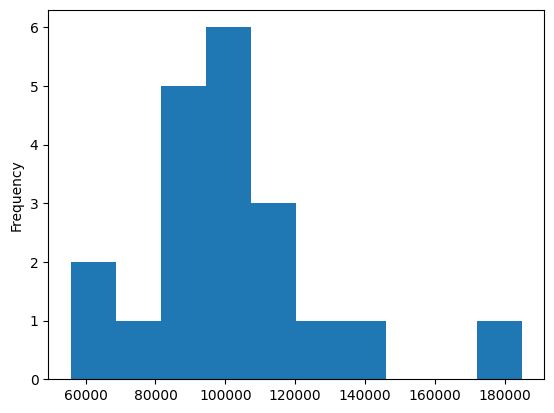

In [121]:
df["ext price"].plot.hist()

In [122]:
df["ext price"].describe()

count        20.000000
mean     101711.287500
std       27037.449673
min       55733.050000
25%       89137.707500
50%      100271.535000
75%      110132.552500
max      184793.700000
Name: ext price, dtype: float64

In [123]:
a = pd.qcut(df["ext price"], q=4)

In [124]:
a.values

[(55733.049000000006, 89137.708], (89137.708, 100271.535], (55733.049000000006, 89137.708], (110132.552, 184793.7], (89137.708, 100271.535], ..., (110132.552, 184793.7], (100271.535, 110132.552], (110132.552, 184793.7], (100271.535, 110132.552], (100271.535, 110132.552]]
Length: 20
Categories (4, interval[float64, right]): [(55733.049000000006, 89137.708] < (89137.708, 100271.535] < (100271.535, 110132.552] < (110132.552, 184793.7]]

In [125]:
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420155
 BldgGrade: 137159.5602262011
 YrBuilt: -3565.4249392493457
 Bedrooms: -51947.38367361445
 Bathrooms: 42396.164527720204
 PropertyType_Townhouse: 84479.16203299582
 SqFtFinBasement: 7.046974967577223
 PropertyType_Single Family: 22912.055187017522


In [126]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [127]:
print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230220172
 BldgGrade: 248997.7936621268
 PropertyType: -3211.7448621550902
 YrBuilt: -19898.49534050206


In [128]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
'BldgGrade', 'PropertyType', 'zip_group']
outcome = 'AdjSalePrice'
X = pd.get_dummies(house[predictors], drop_first=True)
confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])
print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580163
 SqFtLot: 0.4549871385466074
 Bathrooms: 5928.425640001561
 Bedrooms: -41682.87184074457
 BldgGrade: 98541.18352725994
 PropertyType_Single Family: 19323.625287919498
 PropertyType_Townhouse: -78198.72092762352
 zip_group_1: 53317.173306597986
 zip_group_2: 116251.58883563544
 zip_group_3: 178360.53178793364
 zip_group_4: 338408.60185652017


In [129]:
X

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,PropertyType_Single Family,PropertyType_Townhouse,zip_group_1,zip_group_2,zip_group_3,zip_group_4
1,2400,9373,3.00,6,7,False,False,False,True,False,False
2,3764,20156,3.75,4,10,True,False,False,True,False,False
3,2060,26036,1.75,4,8,True,False,False,True,False,False
4,3200,8618,3.75,5,7,True,False,False,True,False,False
5,1720,8620,1.75,4,7,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
27057,1480,5468,1.75,3,7,True,False,False,False,True,False
27058,4720,23914,4.50,4,11,True,False,False,False,False,True
27061,1070,11170,1.00,4,6,True,False,False,False,False,False
27062,1345,6223,2.00,3,7,True,False,False,True,False,False


In [130]:
model = smf.ols(formula='AdjSalePrice ~ SqFtTotLiving * zip_group + SqFtLot + ' +
'Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)

results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Sun, 14 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:20:11   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                     -4.853e+05   2.05e+04    -23.701      0.000   -5.25e+05   -4.45e+05
zip_group[T.1]                -1.113e+04   1.34e+04     -0.830      0.407   -3.74e+04    1.52e+04
zip_group[T.2]                 2.032e+04   1.18e+04      1.717      0.086   -2877.441    4.35e+04
zip_group[T.3]                  2.05e+04   1.21e+04      1.697      0.090   -3180.870    4.42e+04
zip_group[T.4]                -1.499e+05   1.13e+04    -13.285      0.000   -1.72e+05   -1.28e+05
PropertyType[T.Single Family]  1.357e+04   1.39e+04      0.975      0.330   -1.37e+04    4.09e+04
PropertyType[T.Townhouse]     -5.884e+04   1.51e+04     -3.888      0.000   -8.85e+04   -2.92e+04
SqFtTotLiving                   114.7650      4.863     23.600      0.000     105.233     124.297
SqFtTotLiving:zip_group[T.1]     32.6043      5.712      5.708      0.000      21.409      43.799
SqFtTotLiving:zip_group[T.2]     41.7822      5.187      8.056      0.000      31.616      51.948
SqFtTotLiving:zip_group[T.3]     69.3415      5.619     12.341      0.000      58.329      80.354
SqFtTotLiving:zip_group[T.4]    226.6836      4.820     47.032      0.000     217.237     236.131
SqFtLot                           0.6869      0.052     13.296      0.000       0.586       0.788
Bathrooms                     -3619.4533   3202.296     -1.130      0.258   -9896.174    2657.267
Bedrooms                       -4.18e+04   2120.279    -19.715      0.000    -4.6e+04   -3.76e+04
BldgGrade                      1.047e+05   2069.472     50.592      0.000    1.01e+05    1.09e+05
==============================================================================
Omnibus:                    30927.394   Durbin-Watson:                   1.581
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         34361794.502
Skew:                           7.279   Prob(JB):                         0.00
Kurtosis:                     193.101   Cond. No.                     5.80e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.8e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [131]:
house_98105 = house.loc[house['ZipCode'] == 98105, ]
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_98105

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,zip_group
1036,2007-08-16,825000,394500005,Multiplex,2007-08-01,434600,0.998621,826139.0,2,7245,...,6,8,1961,0,2,280000,468000,98105,False,4
1769,2006-12-27,655000,714000130,Single Family,2006-12-01,423400,0.972886,673255.0,1,6750,...,4,8,1946,0,0,350000,417000,98105,False,4
1770,2007-10-11,650000,714000290,Single Family,2007-10-01,431300,0.991039,655878.0,1,6630,...,3,7,1946,0,0,350000,332000,98105,False,4
1771,2006-03-06,580000,714000330,Single Family,2006-03-01,392100,0.900965,643754.0,1,7130,...,3,7,1947,0,0,350000,350000,98105,False,4
1783,2008-05-28,1260000,723000114,Single Family,2008-05-01,407400,0.936121,1345979.0,1,8510,...,5,9,1971,0,0,593000,894000,98105,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26628,2009-06-18,670000,9550204590,Single Family,2009-06-01,357100,0.820542,816533.0,1,3825,...,4,8,1926,0,0,335000,560000,98105,False,4
26629,2015-05-12,475000,9550204620,Single Family,2015-05-01,435200,1.000000,475000.0,1,3825,...,3,7,1925,0,0,335000,295000,98105,False,4
26630,2008-11-20,625000,9550204650,Single Family,2008-11-01,385800,0.886489,705029.0,1,3060,...,5,8,1926,2004,0,259000,513000,98105,False,4
26631,2008-11-03,388000,9550204660,Single Family,2008-11-01,385800,0.886489,437682.0,1,3060,...,1,7,1902,0,0,259000,246000,98105,False,4


In [132]:
house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()


In [133]:
result_98105.summary(
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Sun, 14 Sep 2025   Prob (F-statistic):          1.69e-103
Time:                        20:20:11   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587      0.000     161.574     257.631
SqFtLot          38.9333      5.330      7.305      0.000      28.445      49.421
Bathrooms      2282.2641      2e+04      0.114      0.909    -3.7e+04    4.16e+04
Bedrooms      -2.632e+04   1.29e+04     -2.043      0.042   -5.17e+04    -973.867
BldgGrade        1.3e+05   1.52e+04      8.533      0.000       1e+05     1.6e+05
const         -7.725e+05   9.83e+04     -7.861      0.000   -9.66e+05   -5.79e+05
==============================================================================
Omnibus:                       82.127   Durbin-Watson:                   1.508
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              586.561
Skew:                           0.859   Prob(JB):                    4.26e-128
Kurtosis:                       9.483   Cond. No.                     5.63e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.63e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [134]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal
sresiduals.idxmin() , sresiduals.idxmax()

(np.int64(24333), np.int64(14392))

In [135]:
sresiduals

1036    -2.622626
1769    -0.892439
1770    -0.354599
1771    -1.054669
1783    -0.563783
           ...   
26628    0.085499
26629   -0.544324
26630   -0.355351
26631   -0.049035
26632   -1.480952
Length: 313, dtype: float64

In [136]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


In [137]:
outlier

DocumentDate          2008-12-23
SalePrice                 105000
PropertyID            8819900340
PropertyType       Single Family
ym                    2008-12-01
zhvi_px                   381600
zhvi_idx                0.876838
AdjSalePrice            119748.0
NbrLivingUnits                 1
SqFtLot                     7276
SqFtTotLiving               2900
SqFtFinBasement              320
Bathrooms                    3.0
Bedrooms                       6
BldgGrade                      7
YrBuilt                     1921
YrRenovated                 1960
TrafficNoise                   0
LandVal                   464000
ImpsVal                   284000
ZipCode                    98105
NewConstruction            False
zip_group                      4
Name: 24333, dtype: object

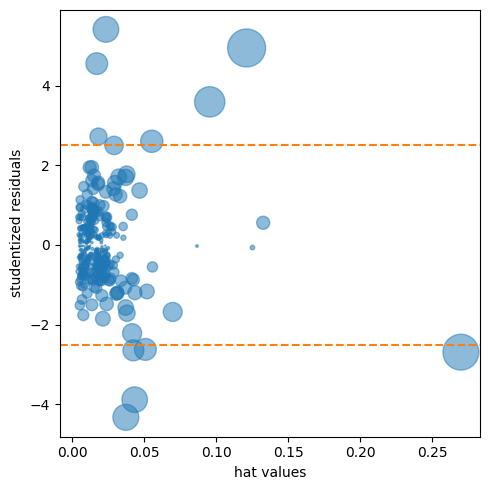

In [138]:


influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal, 
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

%matplotlib inline

plt.tight_layout()
plt.show()

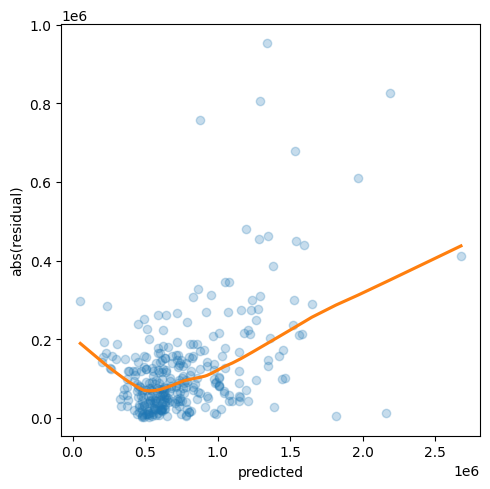

In [139]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid), 
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

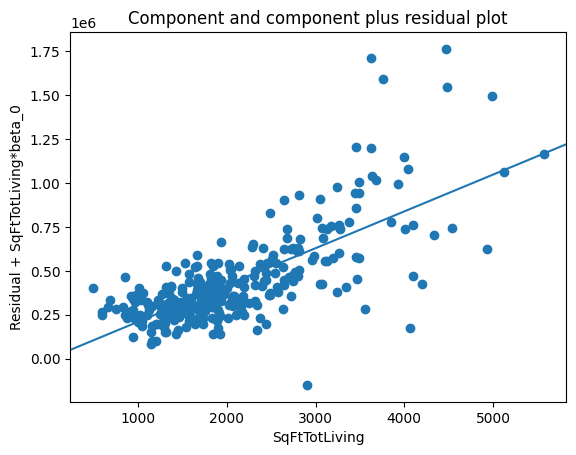

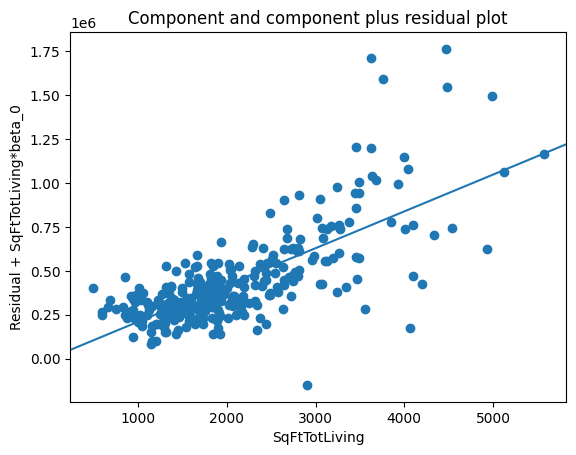

In [140]:
sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving')

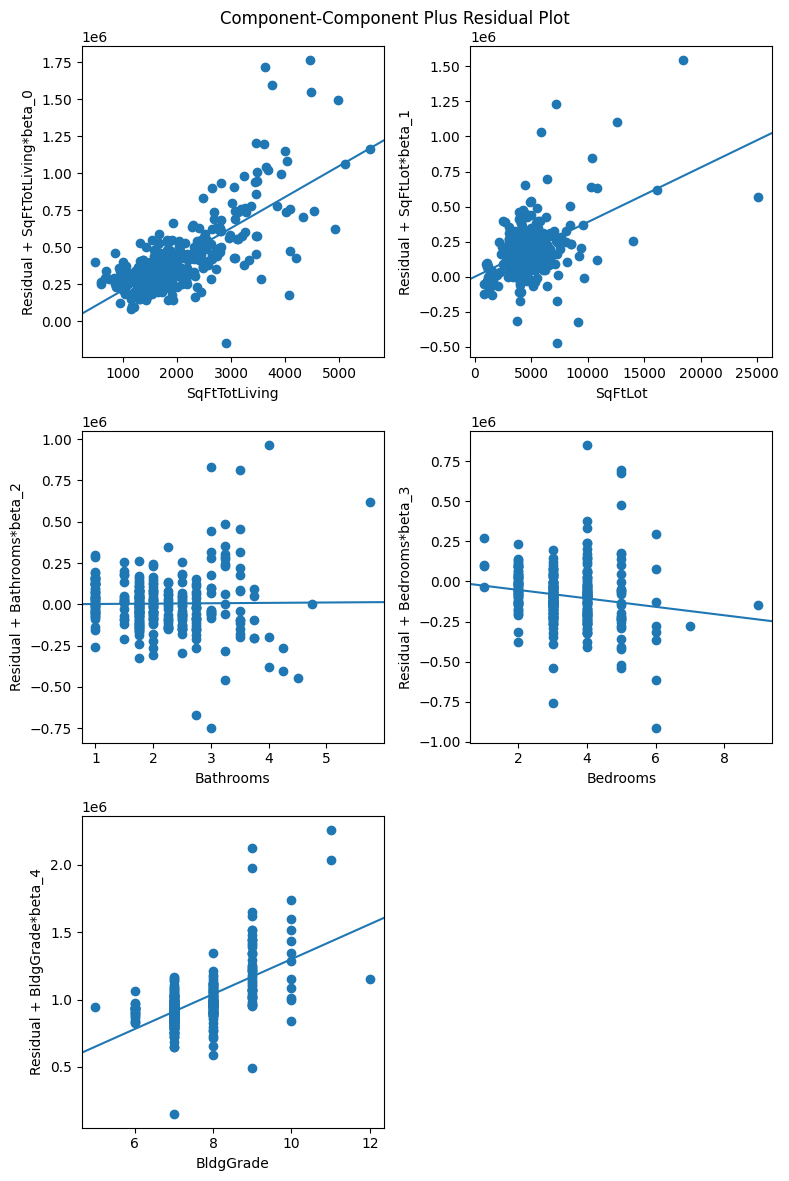

In [141]:
fig = plt.figure(figsize=(8, 12))
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)

In [142]:
model_poly = smf.ols(formula="AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade", data=house_98105)
resuls_poly = model_poly.fit()
resuls_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Sun, 14 Sep 2025   Prob (F-statistic):          9.95e-106
Time:                        20:20:11   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -6.159e+05   1.03e+05     -5.953      0.000   -8.19e+05   -4.12e+05
SqFtTotLiving             7.4521     55.418      0.134      0.893    -101.597     116.501
I(SqFtTotLiving ** 2)     0.0388      0.010      4.040      0.000       0.020       0.058
SqFtLot                  32.5594      5.436      5.990      0.000      21.863      43.256
Bathrooms             -1435.1231   1.95e+04     -0.074      0.941   -3.99e+04     3.7e+04
Bedrooms              -9191.9441   1.33e+04     -0.693      0.489   -3.53e+04    1.69e+04
BldgGrade              1.357e+05   1.49e+04      9.087      0.000    1.06e+05    1.65e+05
==============================================================================
Omnibus:                       75.161   Durbin-Watson:                   1.625
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              637.978
Skew:                           0.699   Prob(JB):                    2.92e-139
Kurtosis:                       9.853   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

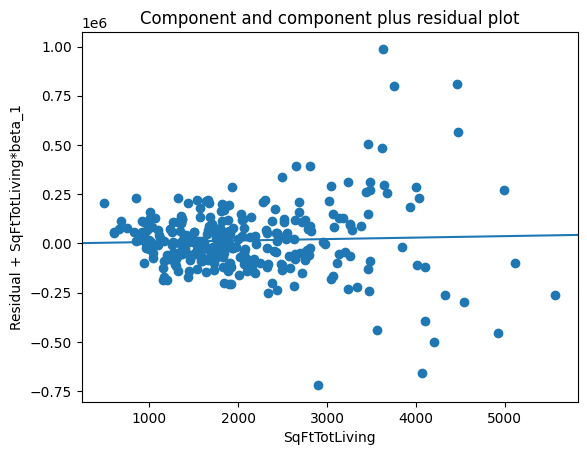

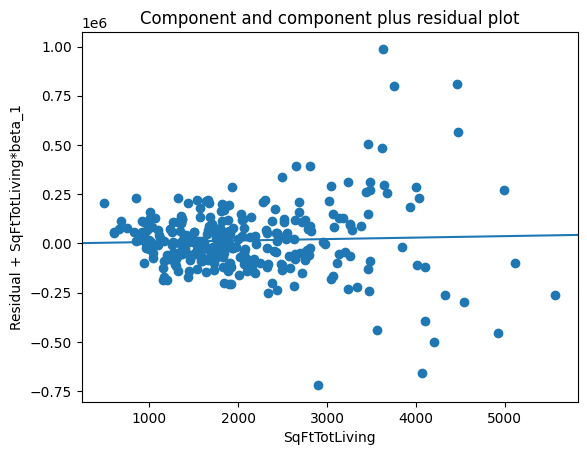

In [143]:
sm.graphics.plot_ccpr(resuls_poly, 'SqFtTotLiving')

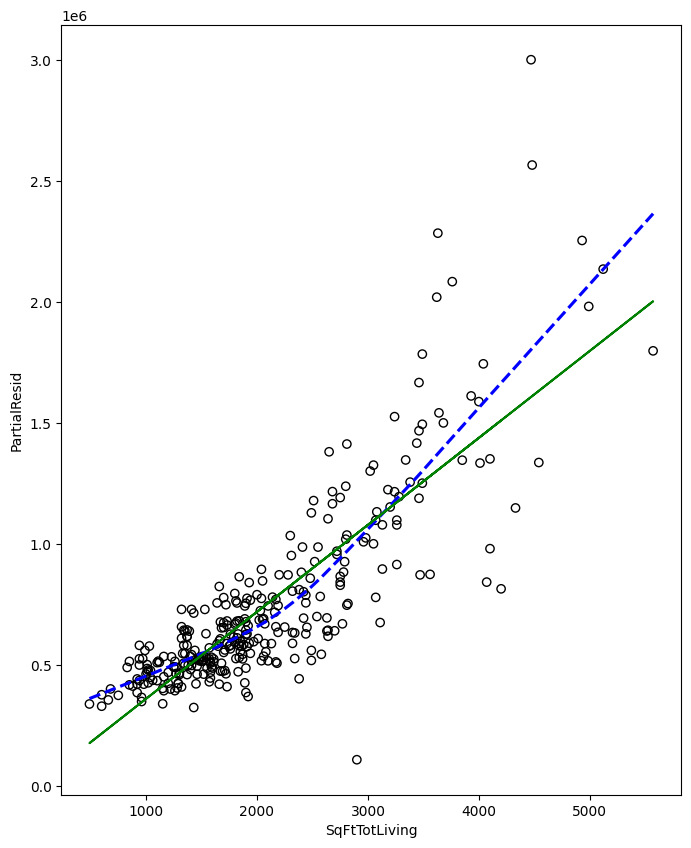

In [144]:
X = house_98105[['SqFtTotLiving']]   # predictor
y = house_98105['AdjSalePrice']             # response variable (replace with yours)

# add intercept
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# get partial residuals
# terms = b_i * X_i (without intercept)
terms = model.params['SqFtTotLiving'] * house_98105['SqFtTotLiving']
partial_resid = model.resid + terms

# build dataframe for plotting
df = pd.DataFrame({
    'SqFtTotLiving': house_98105['SqFtTotLiving'],
    'Terms': terms,
    'PartialResid': partial_resid
})

# plotting
plt.figure(figsize=(8,10))
plt.scatter(x=df['SqFtTotLiving'], y=df['PartialResid'], facecolors='none', edgecolors='black')



# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x='SqFtTotLiving', y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df['SqFtTotLiving'], df['Terms'], color='green')

plt.xlabel("SqFtTotLiving")
plt.ylabel("PartialResid")
plt.show()

In [145]:
X

,const,SqFtTotLiving
1036,1.0,4200
1769,1.0,1920
1770,1.0,1900
1771,1.0,2340
1783,1.0,4010
...,...,...
26628,1.0,2320
26629,1.0,1720
26630,1.0,2420
26631,1.0,1020


In [146]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     697.4
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           1.98e-81
Time:                        20:20:11   Log-Likelihood:                -4290.2
No. Observations:                 313   AIC:                             8584.
Df Residuals:                     311   BIC:                             8592.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.205e+04   3.08e+04      0.392      0.695   -4.85e+04    7.26e+04
SqFtTotLiving   359.5518     13.615     26.408      0.000     332.762     386.342
==============================================================================
Omnibus:                      107.113   Durbin-Watson:                   1.779
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1011.596
Skew:                           1.111   Prob(JB):                    2.16e-220
Kurtosis:                      11.522   Cond. No.                     5.64e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.64e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [147]:
model.params

const            12051.114815
SqFtTotLiving      359.551768
dtype: float64

In [148]:
model.resid

1036    -696029.541249
1769     -29135.509757
1770     -39321.474393
1771    -209648.252400
1783    -107874.705292
             ...      
26628    -29678.217036
26629   -155480.156117
26630   -177137.393856
26631     58888.081622
26632   -321438.509757
Length: 313, dtype: float64

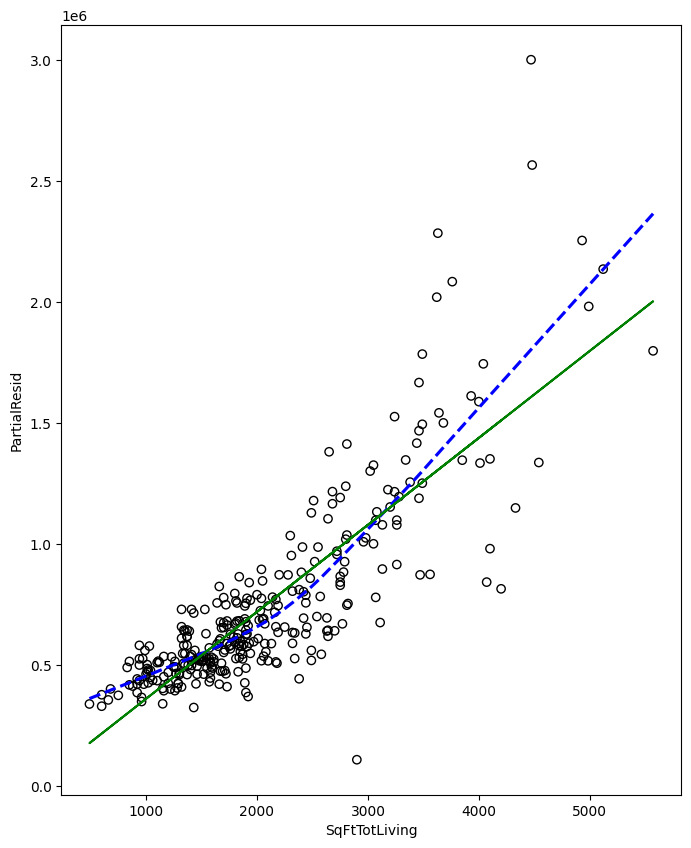

In [149]:
# Partial residual plot by ChatGPT
X = house_98105[['SqFtTotLiving']]   # predictor
y = house_98105['AdjSalePrice']             # response variable (replace with yours)

# add intercept
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# get partial residuals
# terms = b_i * X_i (without intercept)
terms = model.params['SqFtTotLiving'] * house_98105['SqFtTotLiving']
partial_resid = model.resid + terms

# build dataframe for plotting
df = pd.DataFrame({
    'SqFtTotLiving': house_98105['SqFtTotLiving'],
    'Terms': terms,
    'PartialResid': partial_resid
})

# plotting
plt.figure(figsize=(8,10))
plt.scatter(x=df['SqFtTotLiving'], y=df['PartialResid'], facecolors='none', edgecolors='black')

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x='SqFtTotLiving', y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df['SqFtTotLiving'], df['Terms'], color='green')

plt.xlabel("SqFtTotLiving")
plt.ylabel("PartialResid")
plt.show()

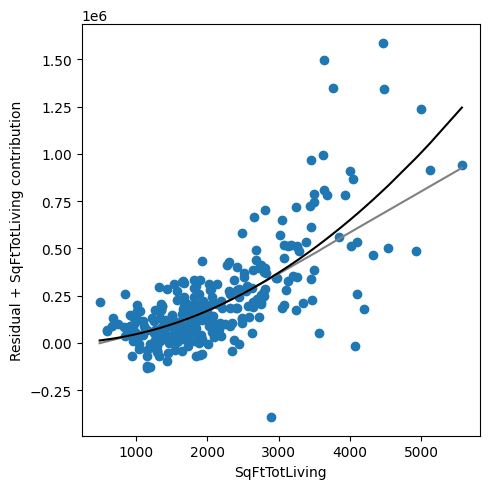

Intercept               -615850.841791
SqFtTotLiving                 7.452134
I(SqFtTotLiving ** 2)         0.038791
SqFtLot                      32.559355
Bathrooms                 -1435.123106
Bedrooms                  -9191.944128
BldgGrade                135717.060127
dtype: float64


In [150]:
# Partial residual plot by the book

def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)
    
    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(resuls_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()
print(resuls_poly.params)


In [151]:
formula = 'AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade'
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()

PatsyError: Error evaluating factor: TypeError: 'BSplines' object is not callable
    AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()


/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_6549/981150082.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# GAM model by the book

from statsmodels.gam.api import GLMGam, BSplines

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ('AdjSalePrice ~ SqFtTotLiving + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

with open("data/output.txt", "w") as f:
    f.write(str(res_sm.summary()))

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                      295
Model Family:                Gaussian   Df Model:                        17.00
Link Function:               Identity   Scale:                      2.7471e+10
Method:                         PIRLS   Log-Likelihood:                -4196.6
Date:                Sun, 14 Sep 2025   Deviance:                   8.1039e+12
Time:                        20:19:16   Pearson chi2:                 8.10e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3.481e+05   1.18e+05  

In [ ]:
res_sm.plot_partial(0, cpr=True, plot_se=True);

In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

gam = LinearGAM(s(0,n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -7833.1159
Number of Samples:                          313 AIC:                                            15683.5863
                                                AICc:                                             15684.14
                                                GCV:                                       30838885095.169
                                                Scale:                                    29480381715.8305
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_6549/489818436.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [ ]:
# Regularization
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler



In [ ]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv("data/house_sales.csv",sep="\t")
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [ ]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X["NewConstruction"] = [1 if nc else 0 for nc in X["NewConstruction"]]

columns = X.columns

# X = StandardScaler().fit_transform(X * 1.0)

y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

LinearRegression()


In [ ]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X,y))

Lasso(alpha=10)


In [ ]:
a = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

a.transpose() @ a

array([[ 66,  78,  90],
       [ 78,  93, 108],
       [ 90, 108, 126]])